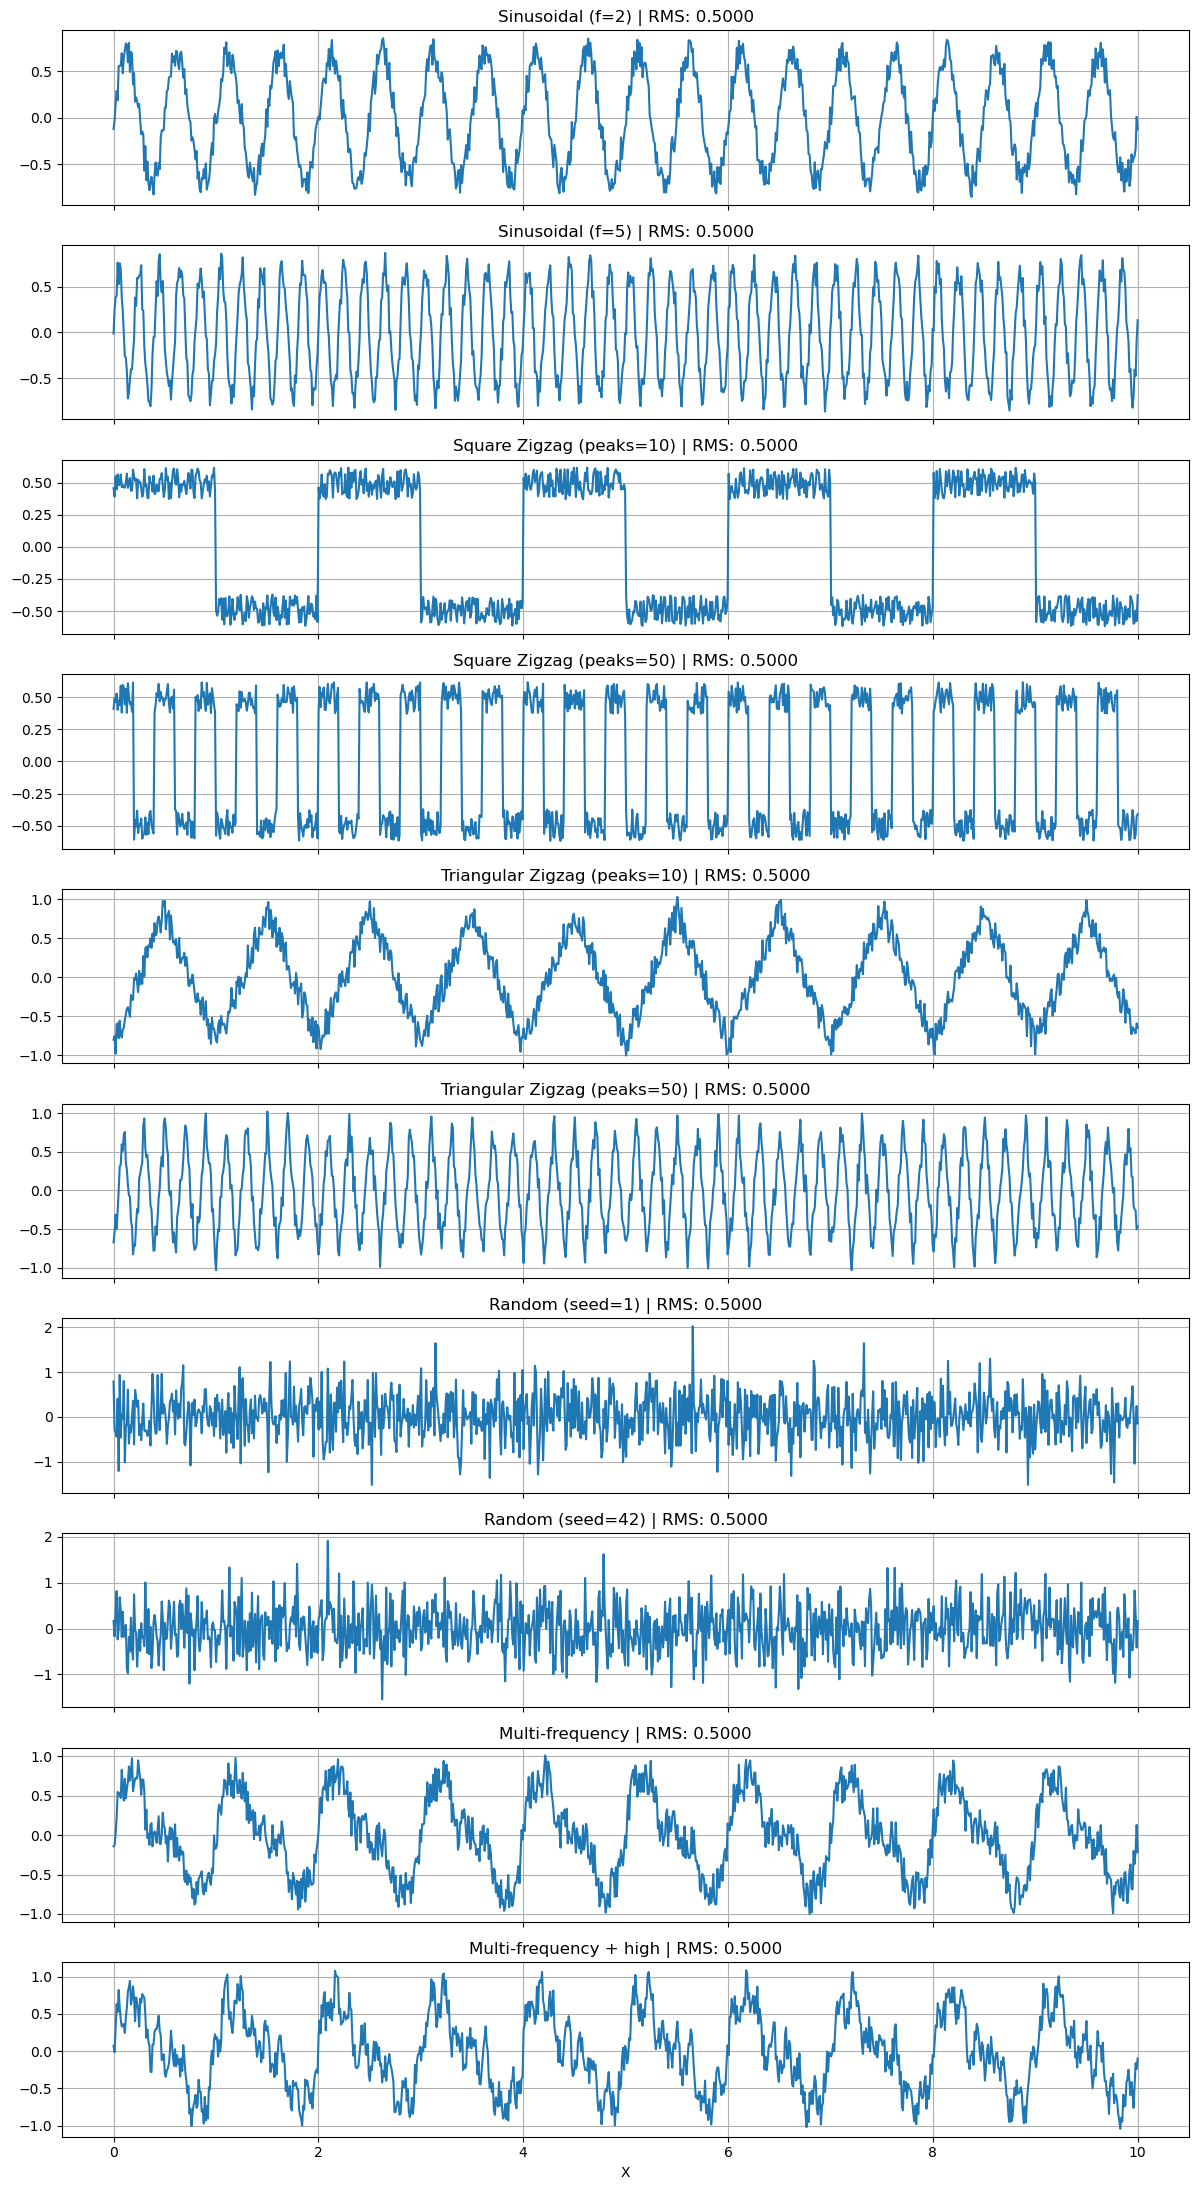

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
num_points = 1000
x = np.linspace(0, 10, num_points)
reference_height = 0.0
target_rms = 0.5
randomness_amplitude = 0.25

def scale_to_rms(y_raw, target_rms, ref=0.0):
    raw_rms = np.sqrt(np.mean((y_raw - ref) ** 2))
    return ref + (target_rms / raw_rms) * (y_raw - ref)

def sinusoidal_profile(frequency):
    y = np.sin(2 * np.pi * frequency * x)
    y += np.random.uniform(-randomness_amplitude, randomness_amplitude, size=num_points)
    return y

def square_zigzag_profile(num_peaks):
    segment_len = num_points // num_peaks
    y = np.zeros_like(x)
    for i in range(num_peaks):
        y[i * segment_len:(i + 1) * segment_len] = 1 if i % 2 == 0 else -1
    y += np.random.uniform(-randomness_amplitude, randomness_amplitude, size=num_points)
    return y[:num_points]

def triangular_zigzag_profile(num_peaks):
    y = np.zeros_like(x)
    period = num_points // num_peaks
    for i in range(num_points):
        t = (i % period) / period
        y[i] = 4 * t - 1 if t < 0.5 else -4 * t + 3
    y += np.random.uniform(-randomness_amplitude, randomness_amplitude, size=num_points)
    return y

def random_profile(seed):
    np.random.seed(seed)
    y = np.random.normal(0, 1, size=num_points)
    y += np.random.uniform(-randomness_amplitude, randomness_amplitude, size=num_points)
    return y

def multifreq_profile(extra_high=False):
    y = 0.6 * np.sin(2 * np.pi * x)
    y += 0.3 * np.sin(4 * np.pi * x)
    y += 0.1 * np.sin(10 * np.pi * x)
    if extra_high:
        y += 0.2 * np.sin(15 * np.pi * x)
    y += np.random.uniform(-randomness_amplitude, randomness_amplitude, size=num_points)
    return y

# --- Generate and Scale Profiles ---
profiles = []
labels = []

# Sinusoidal
for f in [2, 5]:
    y = sinusoidal_profile(f)
    profiles.append(scale_to_rms(y, target_rms))
    labels.append(f"Sinusoidal (f={f})")

# Square Zigzag
for peaks in [10, 50]:
    y = square_zigzag_profile(peaks)
    profiles.append(scale_to_rms(y, target_rms))
    labels.append(f"Square Zigzag (peaks={peaks})")

# Triangular Zigzag
for peaks in [10, 50]:
    y = triangular_zigzag_profile(peaks)
    profiles.append(scale_to_rms(y, target_rms))
    labels.append(f"Triangular Zigzag (peaks={peaks})")

# Random
for seed in [1, 42]:
    y = random_profile(seed)
    profiles.append(scale_to_rms(y, target_rms))
    labels.append(f"Random (seed={seed})")

# Multi-frequency
for hi in [False, True]:
    y = multifreq_profile(extra_high=hi)
    profiles.append(scale_to_rms(y, target_rms))
    labels.append("Multi-frequency" + (" + high" if hi else ""))

# --- Plotting ---
fig, axs = plt.subplots(len(profiles), 1, figsize=(12, 22), sharex=True)
for i, (y, label) in enumerate(zip(profiles, labels)):
    axs[i].plot(x, y)
    rms = np.sqrt(np.mean((y - reference_height) ** 2))
    axs[i].set_title(f"{label} | RMS: {rms:.4f}")
    axs[i].grid(True)

plt.xlabel("X")
plt.tight_layout()
plt.show()


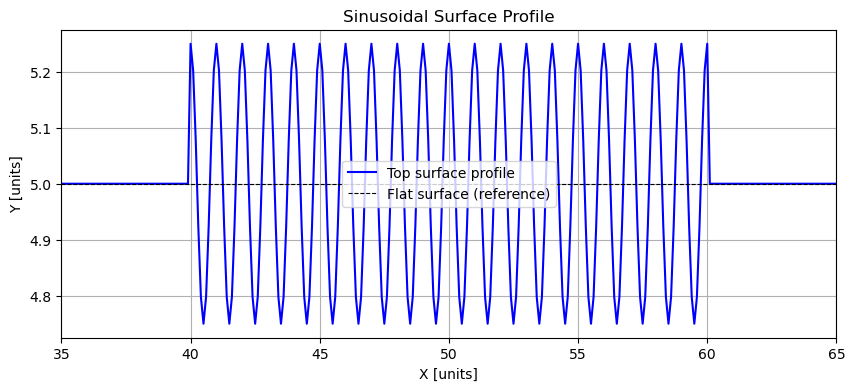

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

# -------------------------------
# Parameters (adjust as needed)
# -------------------------------
width = 100.0     # total width
height = 5.0     # base height
roughness = 0.25  # target RMS (µm)
amplitude = 0.5
wavelength = 1.0
spacing = wavelength / 10
noise_amplitude = 0.0

# Generate x-values along the width
num_points = int(width / spacing) + 1
x_vals = np.linspace(0, width, num_points)

# Sinusoid region parameters
sinusoid_width = 0.2 * width
center = width / 2
left = center - sinusoid_width / 2
right = center + sinusoid_width / 2

phase_shift = math.pi/2 - 2*math.pi*(center - left)/wavelength

# --- Generate y-values ---
y_vals = []
for x in x_vals:
    if x == 0.0 or x == width:
        y_vals.append(height)
    elif left <= x <= right:
        y_vals.append(
            height
            + amplitude * math.sin(2 * math.pi * (x - left) / wavelength + phase_shift)
            + random.uniform(-noise_amplitude, noise_amplitude)
        )
    else:
        y_vals.append(height)

# --- Scale to match target RMS ---
y_offsets = np.array(y_vals) - height
peak = np.max(np.abs(y_offsets))
if peak != 0:
    scale_factor = roughness / peak
    y_vals = height + y_offsets * scale_factor

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(x_vals, y_vals, label="Top surface profile", color="b")
plt.axhline(height, color="k", linestyle="--", linewidth=0.8, label="Flat surface (reference)")
plt.xlabel("X [units]")
plt.xlim(35, 65)
plt.ylabel("Y [units]")
plt.title("Sinusoidal Surface Profile")
plt.legend()
plt.grid(True)
plt.show()


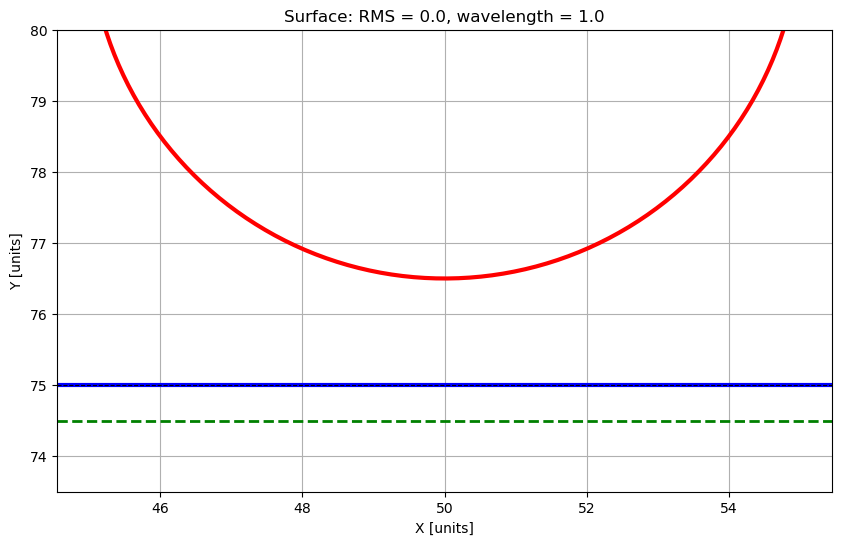

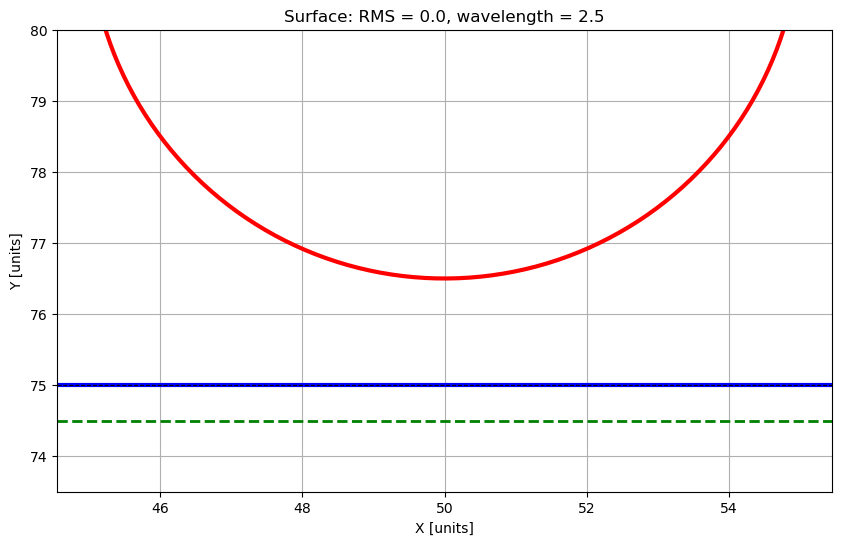

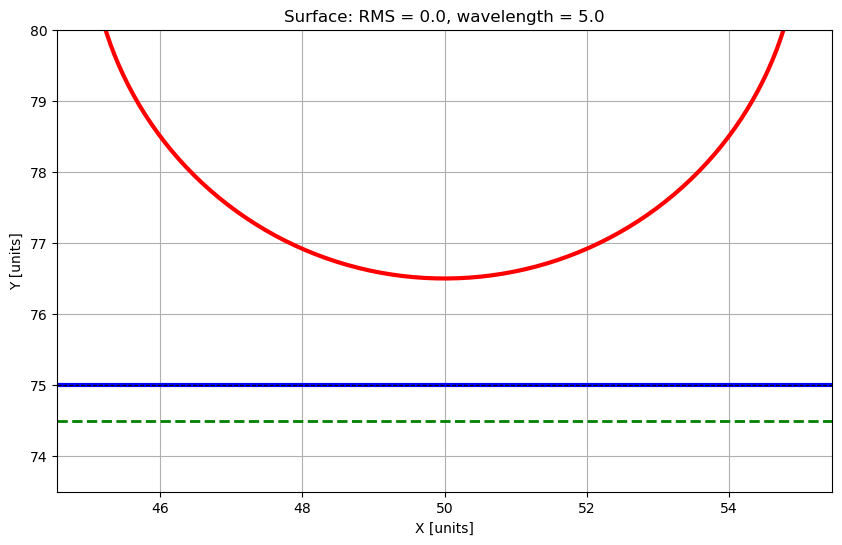

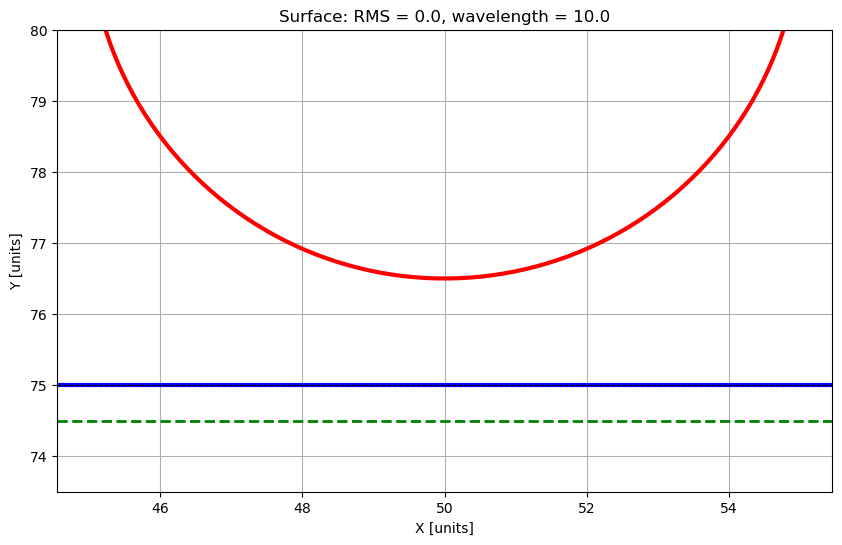

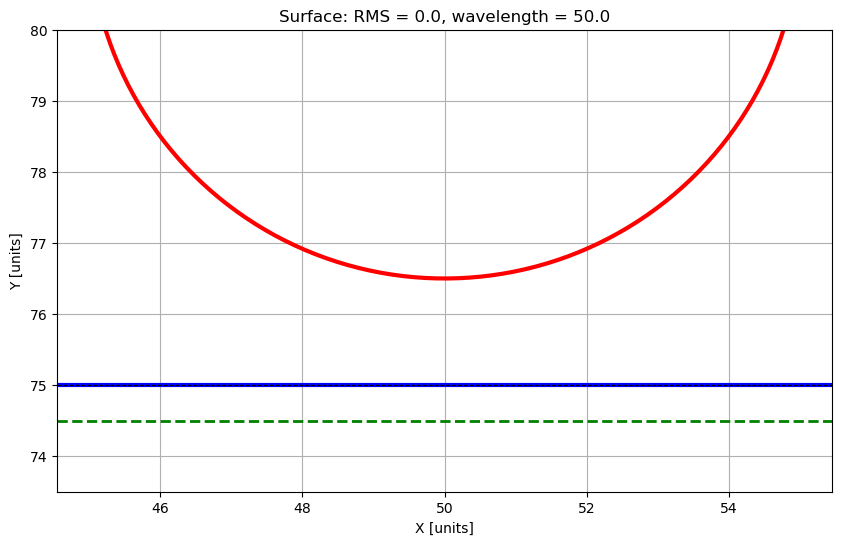

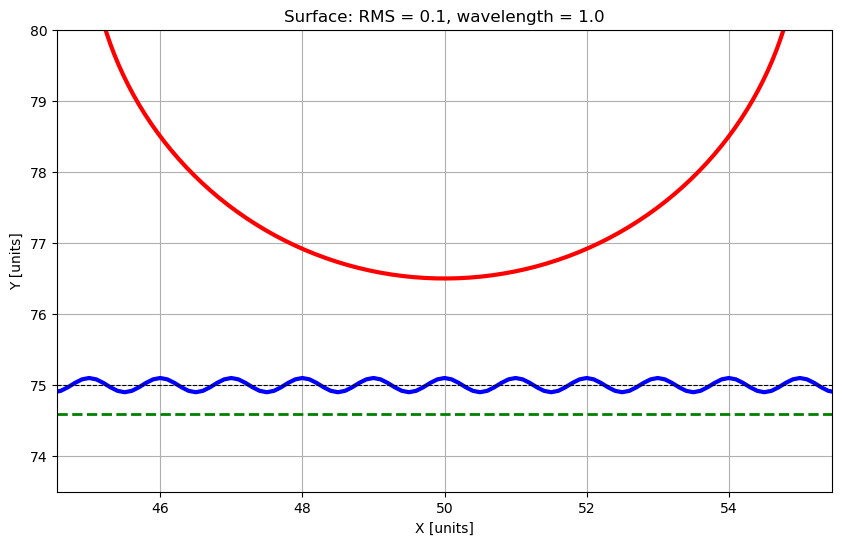

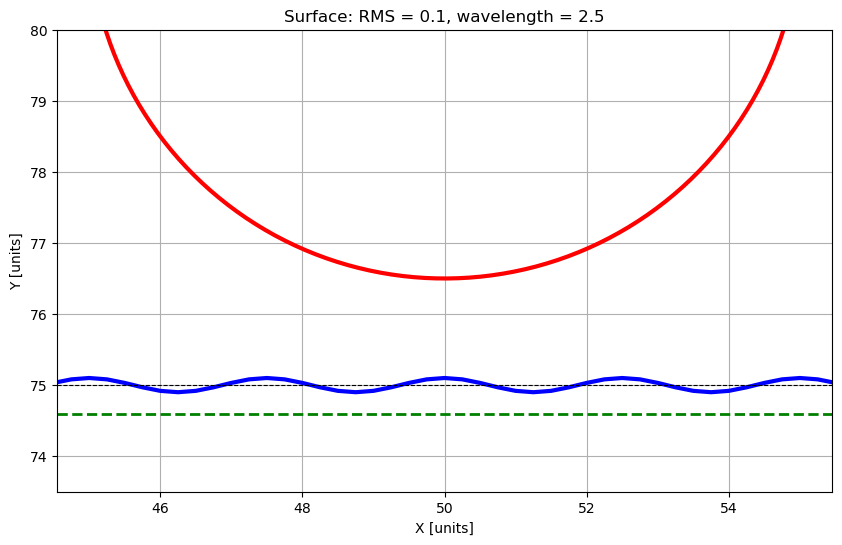

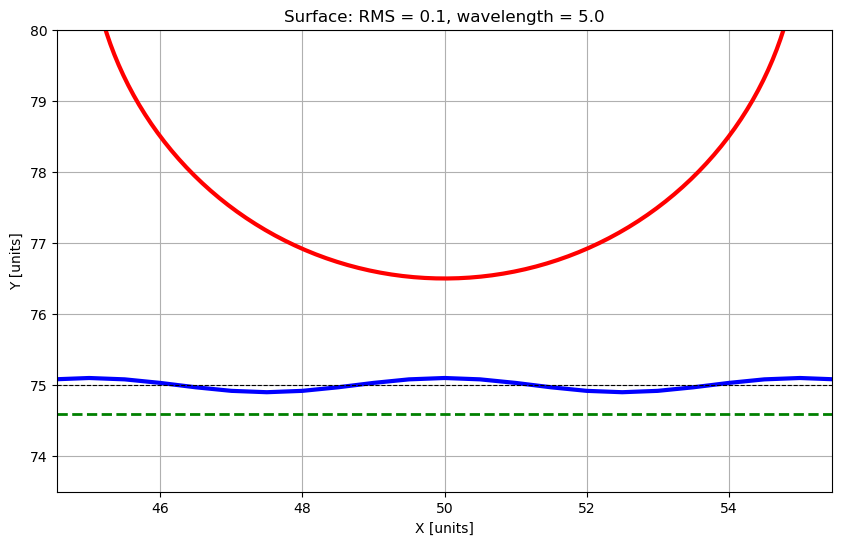

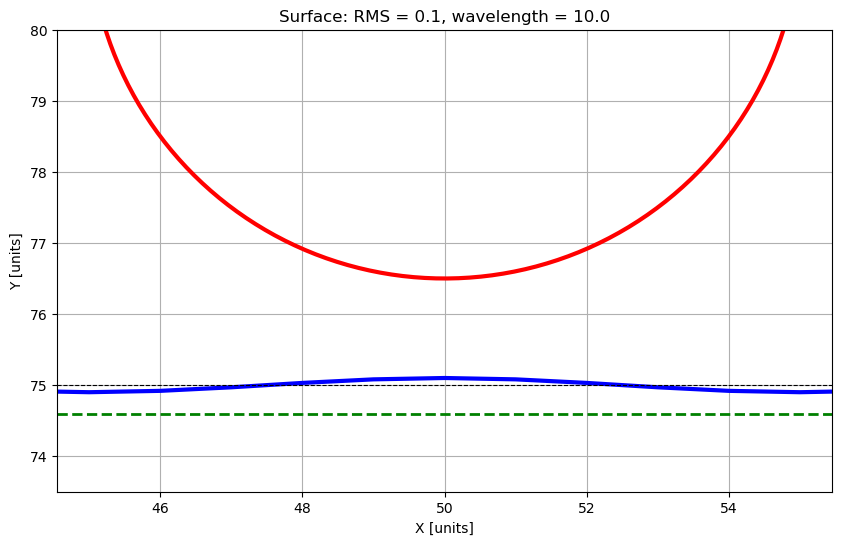

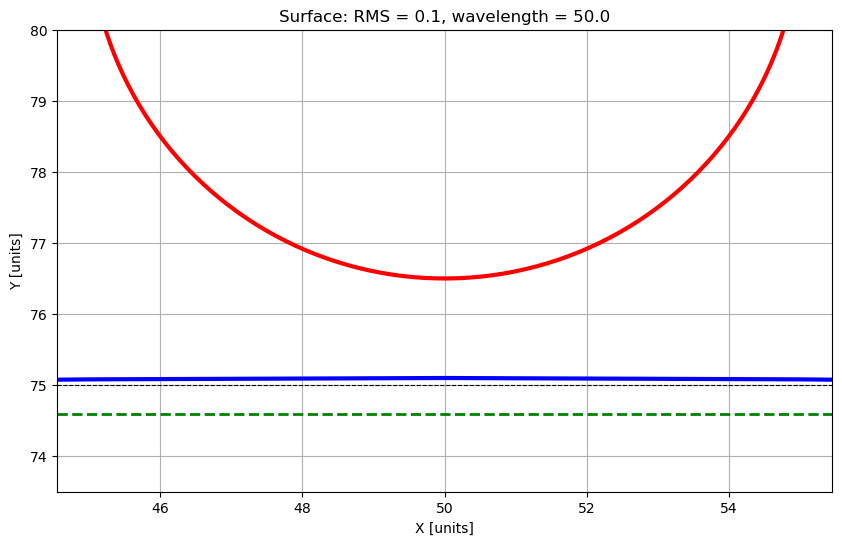

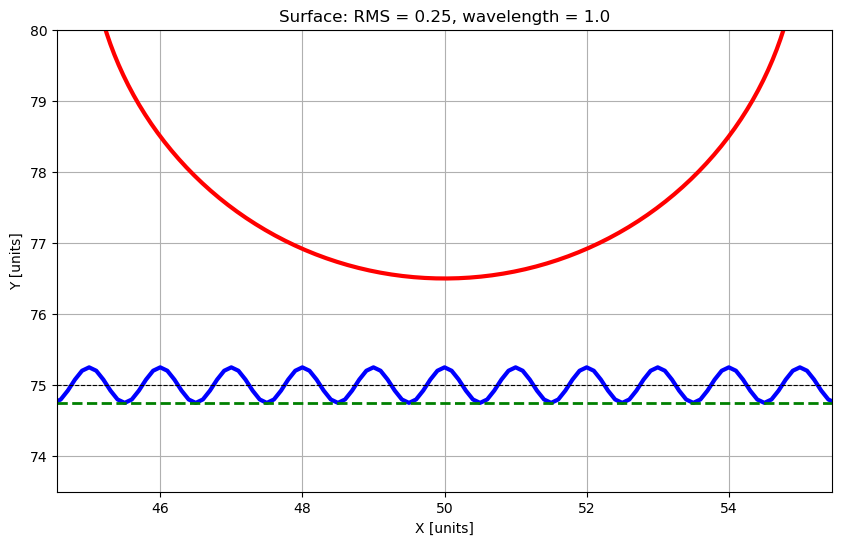

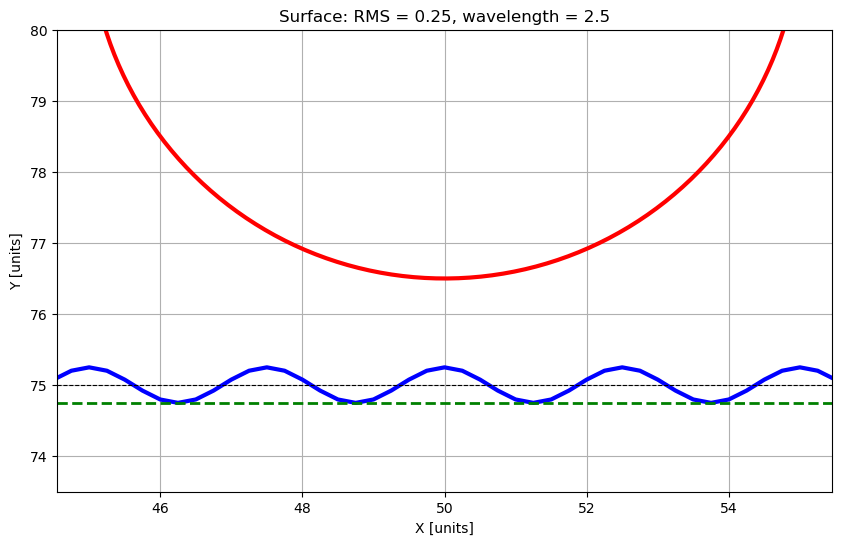

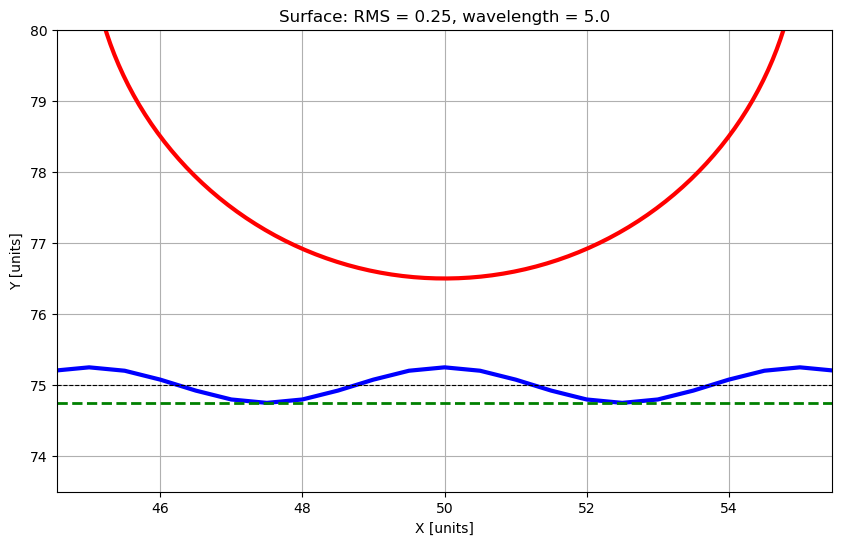

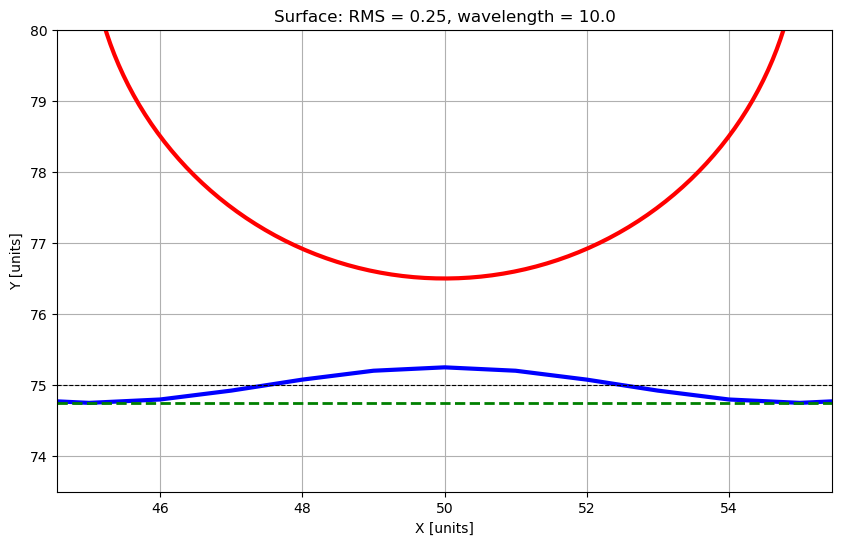

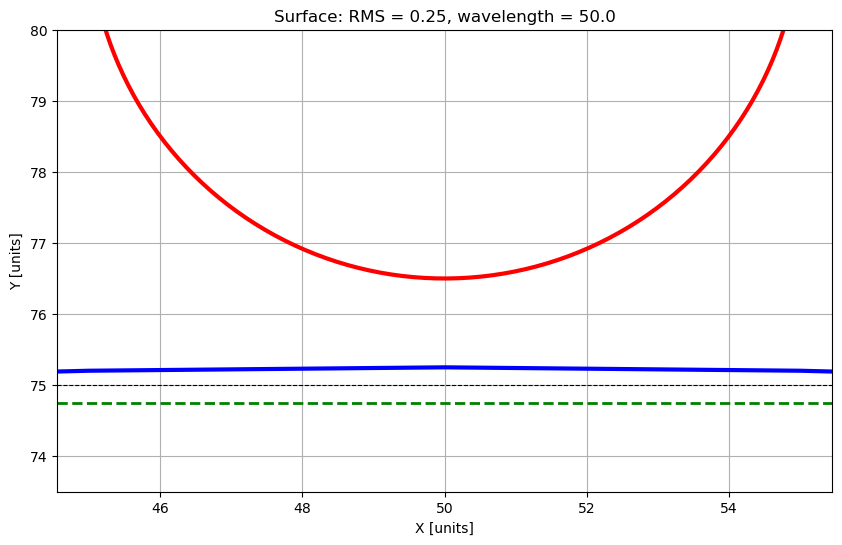

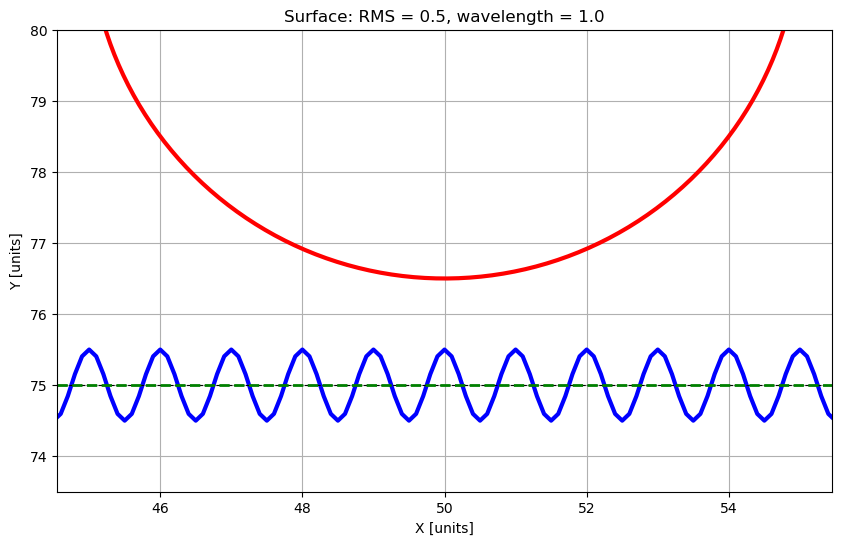

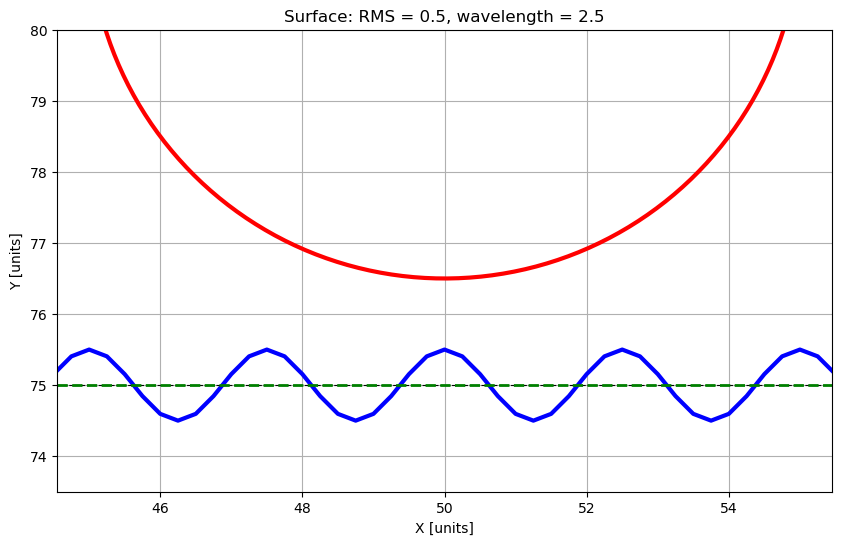

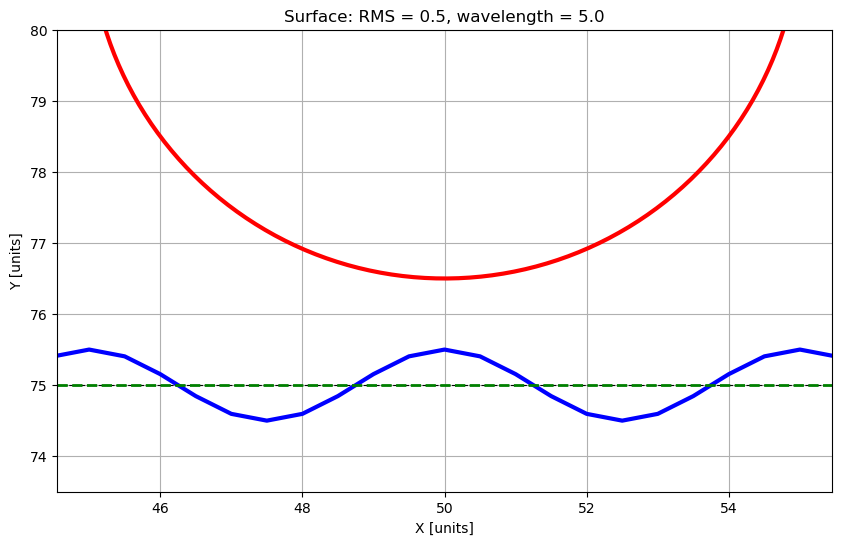

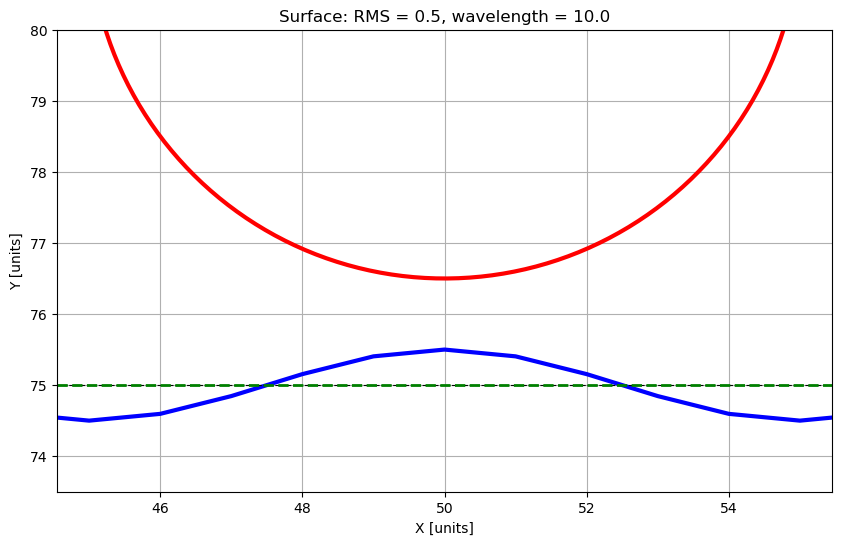

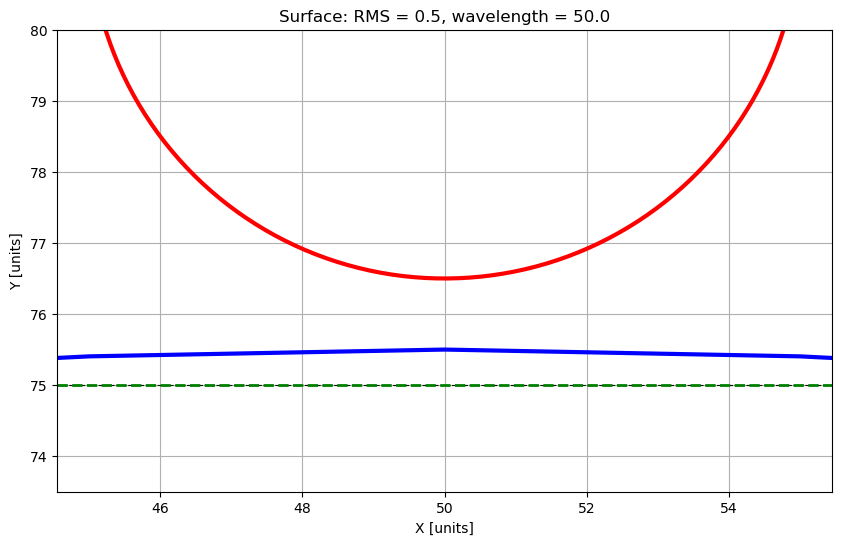

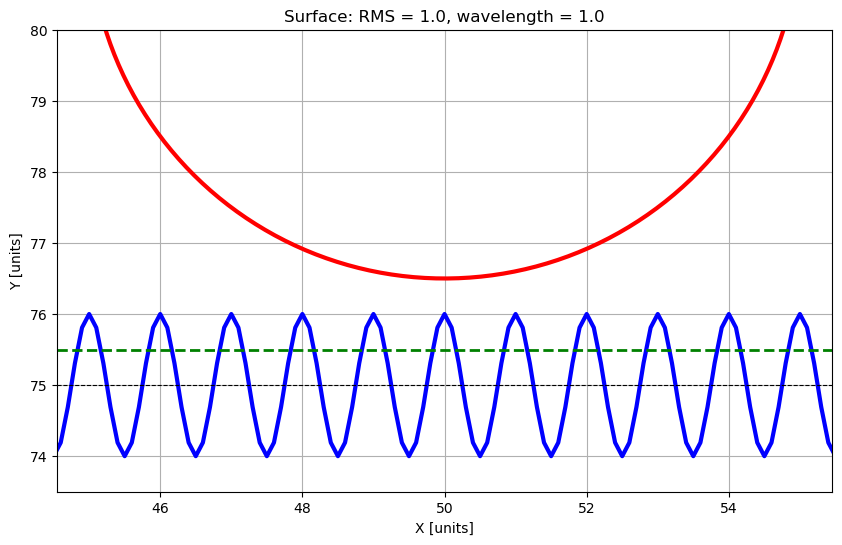

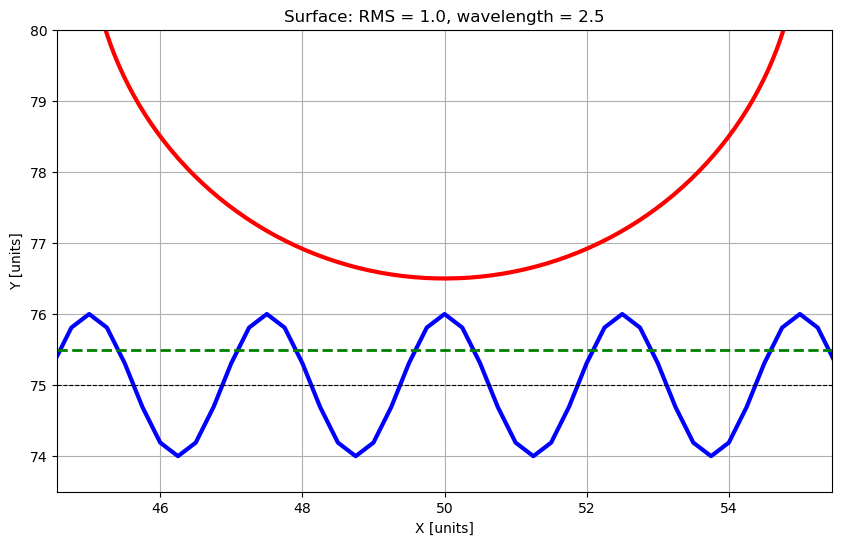

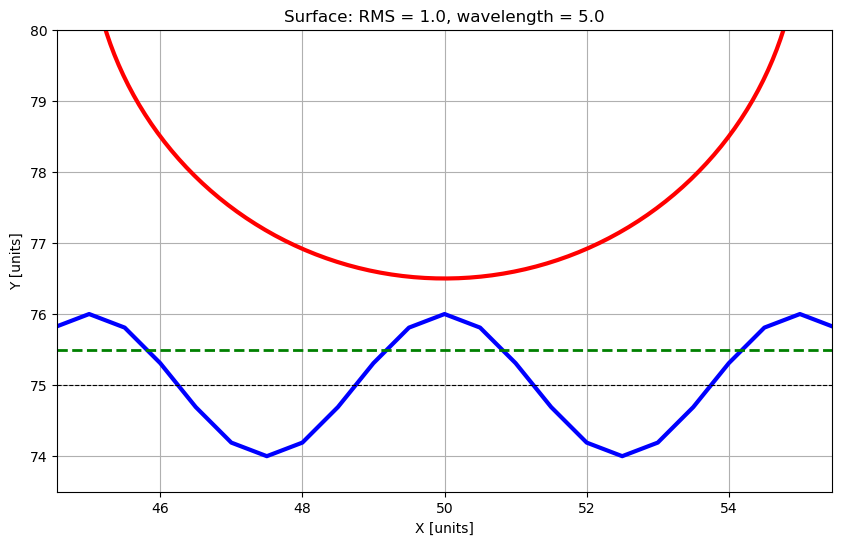

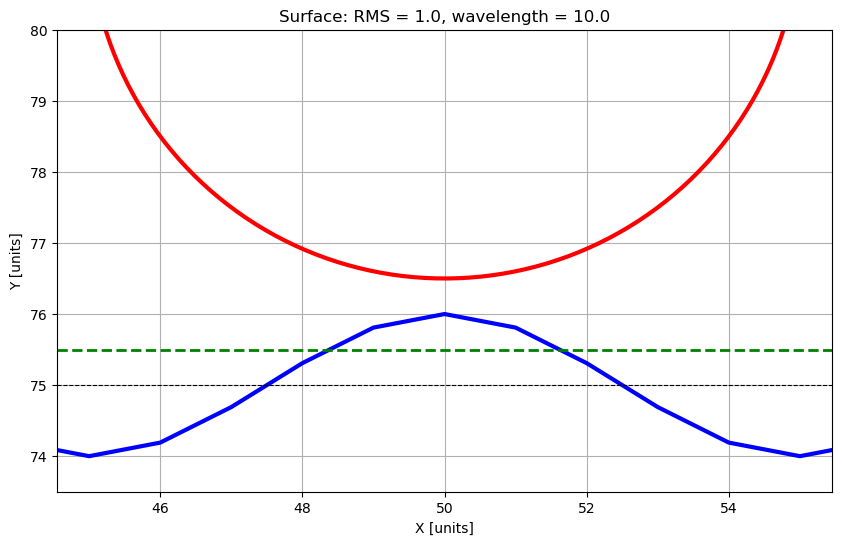

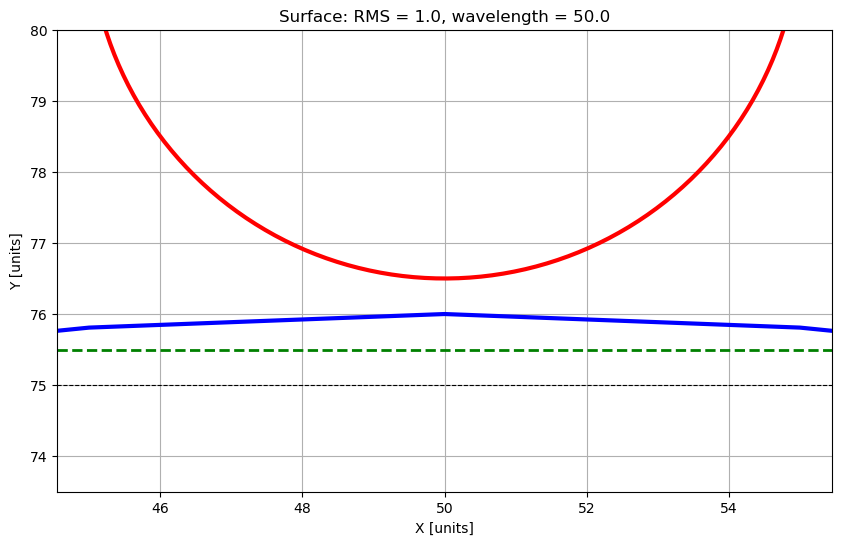

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

rms_array = [0.0, 0.1, 0.25, 0.5, 1.0]
wl_array = [1.0, 2.5, 5.0, 10.0, 50.0]

for rms in rms_array:
    for wl in wl_array:
        # -------------------------------
        # Parameters
        # -------------------------------
        width = 100.0     # surface width
        height = 75.0     # base flat height
        roughness = rms  # target RMS (µm)
        amplitude = 0.5
        wavelength = wl
        spacing = wavelength / 10
        noise_amplitude = 0.0
        
        R = 5.0   # indenter radius
        x0 = width / 2  # center of indenter in x
        y0 = height + R + 1.5  # vertical position of indenter center (offset above surface)
        
        # -------------------------------
        # Generate surface profile
        # -------------------------------
        num_points = int(width / spacing) + 1
        x_vals = np.linspace(0, width, num_points)
        
        # Sinusoid region
        sinusoid_width = 0.2 * width
        center = width / 2
        left = center - sinusoid_width / 2
        right = center + sinusoid_width / 2
        
        phase_shift = math.pi/2 - 2*math.pi*(center - left)/wavelength
        
        y_vals = []
        for x in x_vals:
            if x == 0.0 or x == width:
                y_vals.append(height)
            elif left <= x <= right:
                y_vals.append(
                    height
                    + amplitude * math.sin(2 * math.pi * (x - left) / wavelength + phase_shift)
                    + random.uniform(-noise_amplitude, noise_amplitude)
                )
            else:
                y_vals.append(height)
        
        # Scale to target RMS
        y_offsets = np.array(y_vals) - height
        peak = np.max(np.abs(y_offsets))
        if peak != 0:
            scale_factor = roughness / peak
            y_vals = height + y_offsets * scale_factor
        
        # -------------------------------
        # Generate indenter (semi-circle)
        # -------------------------------
        theta = np.linspace(0, -np.pi, 200)  # semi-circle (π radians)
        x_indenter = x0 + R * np.cos(theta)
        y_indenter = y0 + R * np.sin(theta)
        
        # -------------------------------
        # Visualization
        # -------------------------------
        plt.figure(figsize=(10, 6))
        
        # Surface
        plt.plot(x_vals, y_vals, label=f"Surface: RMS = {roughness}, wavelength = {wavelength}", linewidth = 3.0, color="b")
        
        # Flat reference line
        plt.axhline(height, color="k", linestyle="--", linewidth=0.8, label="Flat reference")
        
        # Indentation depth
        plt.axhline(height + roughness - R * 0.1, color="g", linestyle="--", linewidth=2, label="Indentation depth")
        
        # Indenter
        plt.plot(x_indenter, y_indenter, color="r", linewidth = 3.0, label=f"Semi-circle indenter (R={R})")
        
        
        plt.xlabel("X [units]")
        plt.ylabel("Y [units]")
        plt.title(f"Surface: RMS = {roughness}, wavelength = {wavelength}")
        #plt.legend()
        plt.axis("equal")
        plt.grid(True)
        
        plt.xlim(45.0, 55.0)
        plt.ylim(73.5, 80.0)
        plt.show()
